### This example demonstrates how to use the `spdc.py` functions to generate the JSA and other properties of nonlinear waveguides using the *[Generator of Momentum](https://journals.aps.org/pra/abstract/10.1103/PhysRevA.105.013708)* method. These functions are valid for *arbitrary dispersion* for all modes. Works for arbitrary poling (see `comparing_lin_arb` notebook) but does not include self- and cross-phase modulation.

This method is useful when considering dispersion engineered waveguides where the phase-mismatch, $\Delta k(\omega,\omega')$, does not contain linear frequency-dependent terms (i.e. group-velocity matching). When this is the case, one needs to keep quadratic (and possibly higher order) frequency-dependent terms, at which point the linear method fails. Note that we only consider single-pass waveguides in this note, however, one can readily solve for multi-pass structures by stitching the different propagators in different regions together (as done in the `example_doublepass` notebook). Unlike the linear method, the equations of motion are $z$-dependent and as such the functions take longer to evaluate (few-several minutes).

We consider two different examples: Type-II SPDC where all modes are velocity matched and we truncate the dispersion relations to second order; Type-0 SPDC where we use complete dispersive data from an engineered source (see [Optica Quantum 3, 560 (2025)](https://doi.org/10.1364/OPTICAQ.566703))

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from NeedALight.spdc import SPulsed_arb
from scipy.signal import peak_widths
from scipy.signal import find_peaks

#### Group-velocity matching and quadratic dispersion

This section introduces all relevant quantities needed to use the functions and generate the wanted properties.

In [ ]:
#Parameters for calculations
N = 301  # Number of frequency values
l = 1.0  # amplification region length
sig = 1  # pump wave packet spread

#Dispersions
v = 0.1  # velocity of all modes
bs = 3     #signal group-velocity dispersion
bi = -1    #idler group-velocity dispersion  
bp = -3e-1     #pump group-velocity dispersion
#Frequency values
wi = -10
wf = 10
w = np.linspace(wi, wf, N)
dw = np.abs(w[1]-w[0])
#Dispersion relations
ks = w/v+bs*w**2
ki = w/v+bi*w**2
kp_w = (w+w[:,np.newaxis])/v+bp*(w+w[:,np.newaxis])**2

#Interaction strength
Np = 0.0172 # Number of pump photons: Vary this to modify gain values
gamma = 1/np.sqrt(2 * np.pi * v**3)


#Spatial grid and domain
Ndomain = 1000  # Number of spatial points for non-linear/crystal grid
dz = l / Ndomain
z_list = np.linspace(-l/2,l/2-dz, Ndomain)
domain = np.asarray([1]*len(z_list))


#Defining gaussian pump pulse
def pump(x, Np, scale=1):
    return np.sqrt(Np)*np.exp(-((x) ** 2) / (2 * (sig*scale) ** 2)) / np.power(np.pi * (sig*scale)**2, 1 / 4)

pump_w = lambda x: pump(x, Np)

Before we use our built-in function to generate the wanted properties, we first consider the low-gain approximation for the JSA(the product of the pump envelope and phase-matching functions). For illustrative purposes, we include plots of the pump envelope and phase-matching function as well.

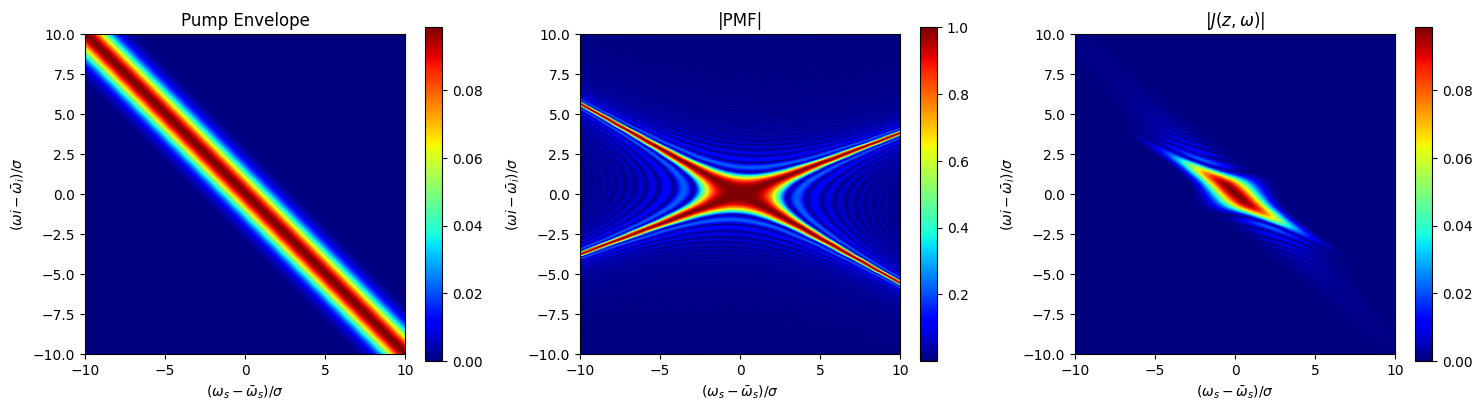

In [5]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
im = axs[0].imshow(pump_w(w+w[:,np.newaxis]), cmap="jet", origin="lower", extent=[w[0],w[-1],w[0],w[-1]])
axs[0].set_xlabel(r"$(\omega_{s}-\bar{\omega}_{s})/\sigma$")
axs[0].set_ylabel(r"$(\omega{i}-\bar{\omega}_{i})/\sigma$")
axs[0].set_title('Pump Envelope')
plt.colorbar(im, orientation="vertical")

im1 = axs[1].imshow(np.abs(np.sinc((kp_w-ks[:,np.newaxis]-ki)*l/(2*np.pi))), cmap="jet", origin="lower", extent=[w[0],w[-1],w[0],w[-1]])
axs[1].set_xlabel(r"$(\omega_{s}-\bar{\omega}_{s})/\sigma$")
axs[1].set_ylabel(r"$(\omega{i}-\bar{\omega}_{i})/\sigma$")
axs[1].set_title('|PMF|')
plt.colorbar(im1, orientation="vertical")

im2 = axs[2].imshow(np.abs(pump_w(w+w[:,np.newaxis])*np.sinc((kp_w-ks[:,np.newaxis]-ki)*l/(2*np.pi))), cmap="jet", origin="lower", extent=[w[0],w[-1],w[0],w[-1]])
axs[2].set_xlabel(r"$(\omega_{s}-\bar{\omega}_{s})/\sigma$")
axs[2].set_ylabel(r"$(\omega{i}-\bar{\omega}_{i})/\sigma$")
axs[2].set_title(r"$|J(z, \omega)|$")
plt.colorbar(im2, orientation="vertical")

fig.tight_layout()
plt.show()

We can also obtain an approximate value for the low-gain Schmidt number as well as the Schmidt modes (Note that these agree with the Schmidt number and first temporal mode structure when using the built in function in the low-gain regime):

In [7]:
L2, D, Vh = np.linalg.svd(0.000000001*pump_w(w+w[:,np.newaxis])*np.sinc((kp_w-ks[:,np.newaxis]-ki)*l/(2*np.pi)))  #SVD of low-gain JSA
u_low = L2[:,0] #Isolating first signal schmidt mode
#Obtaining low-gain Schmidt number
D = np.diag(D)
K_low = (np.trace(np.sinh(D) ** 2)) ** 2 / np.trace(np.sinh(D) ** 4)
print('Approximate Schmidt number in the low-gain is %f' %K_low)

Approximate Schmidt number in the low-gain is 2.068980


Next we consider the JSA, average photon number, and Schmidt number for a higher value of gain (determined by Np above).

In [8]:
T, J, Ns, K, M, Nums, Numi = SPulsed_arb(ks, ki, kp_w, gamma, w, z_list, domain, pump_w)

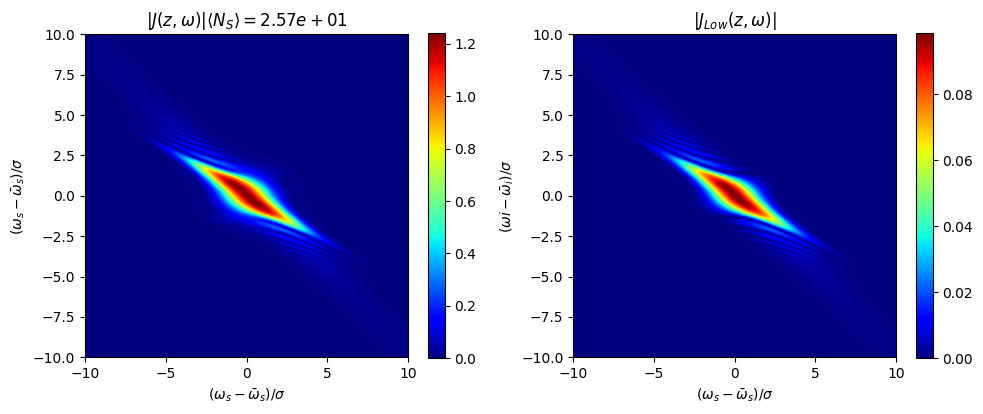

The Schmidt number is 1.312054


In [10]:
# Generating plot for the abs(JSA)
fig, ax = plt.subplots(1, 2, figsize=(10,4))
im = ax[0].imshow(np.abs(J),cmap="jet",origin="lower",extent=[w[0] ,w[-1],w[0] ,w[-1]])
ax[0].set_xlabel(r"$(\omega_{s}-\bar{\omega}_{s})/\sigma$")
ax[0].set_ylabel(r"$(\omega_{s}-\bar{\omega}_{s})/\sigma$")
ax[0].set_title(r"$|J(z, \omega)|    \langle N_{S} \rangle = %1.2e $" % Ns)
plt.colorbar(im, orientation="vertical")

im2 = ax[1].imshow(np.abs(pump_w(w+w[:,np.newaxis])*np.sinc((kp_w-ks[:,np.newaxis]-ki)*l/(2*np.pi))), cmap="jet", origin="lower", extent=[w[0],w[-1],w[0],w[-1]])
ax[1].set_xlabel(r"$(\omega_{s}-\bar{\omega}_{s})/\sigma$")
ax[1].set_ylabel(r"$(\omega{i}-\bar{\omega}_{i})/\sigma$")
ax[1].set_title(r"$|J_{Low}(z, \omega)|$")
plt.colorbar(im2, orientation="vertical")

fig.tight_layout()
plt.show()

print('The Schmidt number is %f' %K)

For the chosen dispersion, the high-gain effects on the JSA are minimal. However, the Schmidt number is reduced greatly. We can also consider how the Schmidt modes behave. Here we consider the first Schmidt mode. We choose a gauge where the imaginary part of the mode is zero at the central frequency.

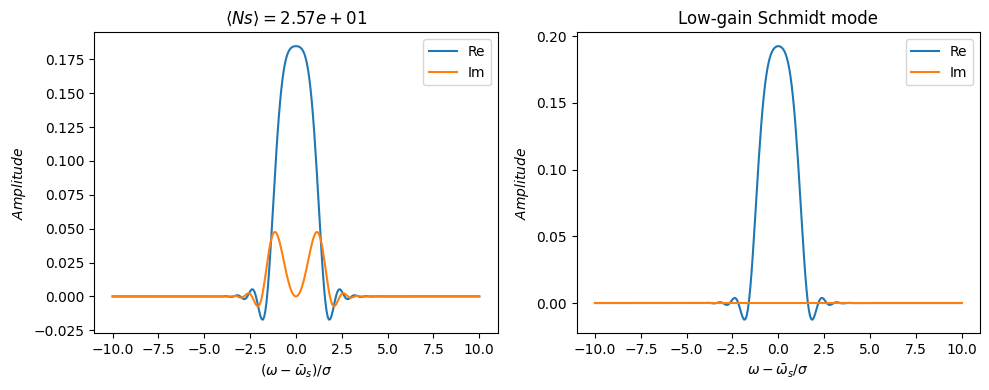

In [11]:
#Looking at the temporal modes via Nums matrix
mark=1 #this just takes the first eigenmode of interest. Choose a different value to look at different ones.
val, u = np.linalg.eigh(Nums)

fig, ax = plt.subplots(1, 2, figsize=(10,4))

ax[0].plot(w, np.real(np.exp(-1j*np.angle(u[(N-1)//2,-mark]))*u[:,-mark]), label='Re') #Here we multiply by a phase factor such that the imaginary part is 0 at the origin.
ax[0].plot(w, np.imag(np.exp(-1j*np.angle(u[(N-1)//2,-mark]))*u[:,-mark]), label='Im')
ax[0].set_xlabel(r"$(\omega-\bar{\omega}_{s})/\sigma$")
ax[0].set_ylabel(r"$Amplitude$")
ax[0].set_title(r"$\langle Ns \rangle= %1.2e$" %Ns)
ax[0].legend()

ax[1].plot(w, np.real(np.exp(-1j*np.angle(u_low[(N-1)//2]))*u_low), label='Re') #Here we multiply by a phase factor such that the imaginary part is 0 at the origin.
ax[1].plot(w, np.imag(np.exp(-1j*np.angle(u_low[(N-1)//2]))*u_low), label='Im')
ax[1].set_xlabel(r"$\omega-\bar{\omega}_{s}/\sigma$")
ax[1].set_ylabel(r"$Amplitude$")
ax[1].set_title("Low-gain Schmidt mode")
ax[1].legend()

fig.tight_layout()
plt.show()

We see that high-gain effects induce an imaginary part to the Schmidt modes.

#### Type-0 with complete dispersive data

We begin by loading pre-saved dispersive data and renormalizing such that we work in units of nanometers and terahertz. The data corresponds to an SPDC process where a pump photon at 1045 nm generates signal photons at 2090 nm. The waveguide structure is such that $v_{S}=v_{P}$ (group-velocity matching) and $\beta_{S}\gg\beta_{P}$ (group-velocity dispersion condition). The pump envelope is chosen to minimize the Schmidt number (maximize spectral purity).

We consider a slightly different analyis which outputs some of the results presented in [Optica Quantum 3, 560 (2025)](https://doi.org/10.1364/OPTICAQ.566703)

In [13]:
#Renormalize such that units are in nm and THz
l2 = 0.01 * 1e9  #Length of crystal
ww = np.load('data/frequency.npy') * 1e-12 #Signal frequencies
dw2 = np.abs(ww[1]-ww[0])
ks2 = np.load('data/ks.npy') * 1e-9  #Signal dispersion relation ks(w)
kp_w2 = np.load('data/kp_w.npy') * 1e-9 #Pump dispersion relation matrix kp(w+w')

#Pump envelope in frequency space
sig_w2 = 33.3
pump_w2 = lambda x: 1e-3*np.exp(-(x ** 2) / (2 * sig_w2**2)) / np.power(
    np.pi * (sig_w2) ** 2, 1 / 4
)

# Interaction strength
Np2 = 5.26e-10  # low-gain: 1.857e-14. Currently set to high-gain
gamma2 = np.sqrt(Np2 / (
    2 * np.pi * 0.442**3))   #0.442 corresponds to group-velocity/speed of light

# Spatial grid and domain
Ndomain2 = 1000  # Number of spatial points for non-linear/crystal grid
dz2 = l2 / Ndomain2
z_list2 = np.linspace(-l2/2,l2/2-dz2,1000)
domain2 = np.asarray([1]*len(z_list2))


In [14]:
T_data, J_data, Ns_data, K_data, M_data, Nums_data, Numi_data = SPulsed_arb(ks2, ks2, kp_w2, gamma2, ww, z_list2, domain2, pump_w2)

Looking at the JSA, Ns, and Schmidt number.

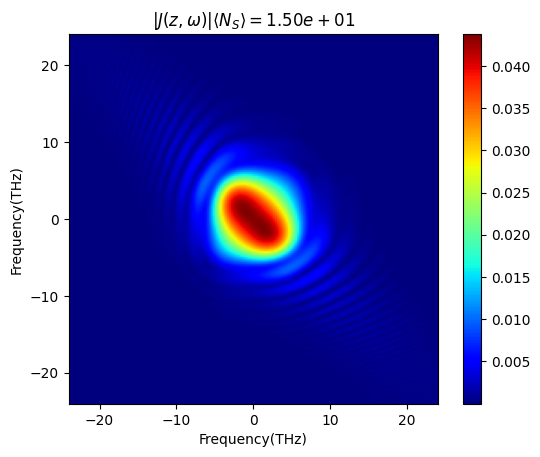

The Schmidt number is 1.022518


In [15]:
# Generating plot for the abs(JSA) in terms of frequency(f)
fig, ax = plt.subplots()
im = ax.imshow(np.abs(J_data),cmap="jet",origin="lower",extent=[ww[0] / (2 * np.pi),ww[-1] / (2 * np.pi),ww[0] / (2 * np.pi),ww[-1] / (2 * np.pi)])
ax.set_xlabel("Frequency(THz)")
ax.set_ylabel("Frequency(THz)")
ax.set_title(r"$|J(z, \omega)|    \langle N_{S} \rangle = %1.2e $" % Ns_data)
plt.colorbar(im, orientation="vertical")
plt.show()

print('The Schmidt number is %f' %K_data)

We now look at the temporal mode structure of the first mode, and obtain its bandwidth of operation (by considering the width of the intensity i.e. $|\psi(\omega)|^2$). We choose a gauge where the imaginary part of the mode is zero at the central frequency.

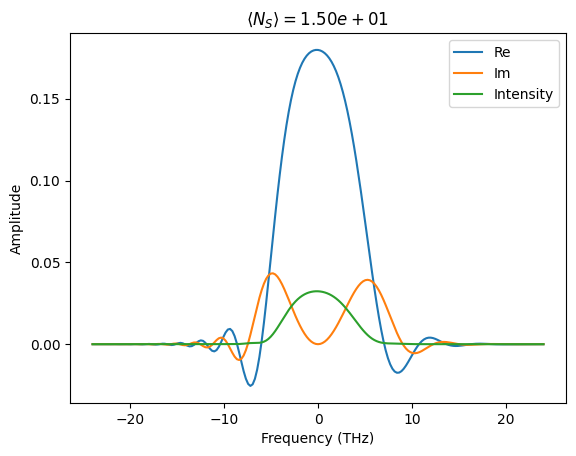

The operational bandwidth is 7.426683 THz


In [16]:
# Looking at the temporal modes via Nums matrix
mark = 1  # this just takes the first eigenmode of interest. Choose a different value to look at different ones.
val_data, u_data = np.linalg.eigh(Nums_data)

# This is to find the width of the intensity at half-max
diag = np.abs(u_data[:, -mark]) ** 2
peaks, _ = find_peaks(diag, height=0.025)
result_half = peak_widths(diag, peaks, rel_height=0.5)
results_half = peak_widths(diag, peaks, rel_height=0.5)

# Plotting the temporal mode in terms of frequency (f)
fig, ax1 = plt.subplots()
ax1.plot(
    ww / (2 * np.pi),
    np.real(np.exp(-1j * np.angle(u_data[(len(ww) - 1) // 2, -mark])) * u_data[:, -mark]),
    label="Re",
)  # Here we multiply by a phase factor such that the imaginary part is 0 at the origin.
ax1.plot(
    ww / (2 * np.pi),
    np.imag(np.exp(-1j * np.angle(u_data[(len(ww) - 1) // 2, -mark])) * u_data[:, -mark]),
    label="Im",
)
ax1.plot(ww / (2 * np.pi ), diag, label="Intensity")
ax1.set_xlabel("Frequency (THz)")
ax1.set_ylabel("Amplitude")
ax1.set_title(r"$\langle N_{S} \rangle= %1.2e$" % Ns_data)
ax1.legend()
plt.show()

print(
    "The operational bandwidth is %f THz"
    % (results_half[0][0] * (ww[1] - ww[0]) / (2 * np.pi))
)

Next we look at the mode occupation fraction for the first five modes. The fraction we consider is $\frac{\sinh^2 r_{i}}{\sum_{k} \sinh^2 r_{k}}$. We also output the ratio of the first/second mode.

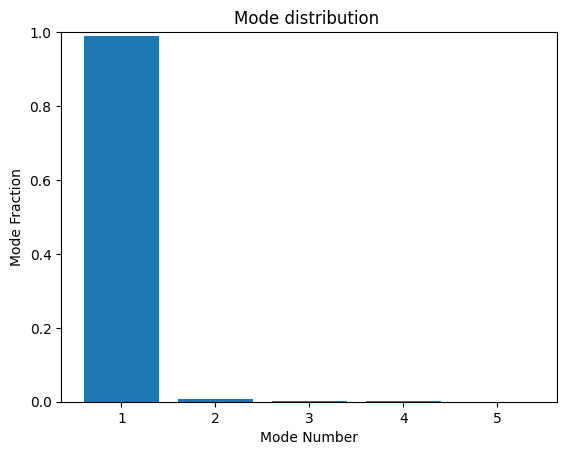

Ratio of first/second mode occupation is: 0.988901/0.006890


In [17]:
#Obtaining weights from eigenvalues of Nums matrix
Weight = np.flip(val_data[-5::]/np.sum(val_data))

fig, ax1 = plt.subplots()

ax1.bar(
    [1, 2, 3, 4, 5], Weight
)  # Here we multiply by a phase factor such that the imaginary part is 0 at the origin.
ax1.set_ylim([0, 1])
ax1.set_xlabel(r"Mode Number")
ax1.set_ylabel(r"Mode Fraction")
ax1.set_title(r"Mode distribution ")
plt.show()
print("Ratio of first/second mode occupation is: %f/%f" % (Weight[0], Weight[1]))